In [58]:
import json

In [72]:
path = "../../emergent-misalignment/open_models/generated_pretrained_comparison_results/output_orig.json"

In [73]:
# from a file
with open(path, "r") as f:
    data = json.load(f)

In [74]:
import json
import pandas as pd
import numpy as np

by_prompt_type = {x: v["agg_combined_prompt_type"] for x, v in data.items()}
# --- Flatten into a DataFrame ---
rows = []
for filepath, entries in by_prompt_type.items():
    # Extract learning rate from filename
    # lr = filepath.split('_resp_')[1].replace('_fpq.csv', '')
    for entry in entries:
        rows.append(entry)

df = pd.DataFrame(rows)
metrics = ['harmless_mean_diff', 'harmless_std_diff', 'aligned_mean_diff', 'aligned_std_diff']

In [64]:

# print("=" * 60)
# print("OVERALL SUMMARY STATISTICS")
# print("=" * 60)
# print(df[metrics].describe().round(3).to_string())

# print("\n" + "=" * 60)
# print("BY PROMPT TYPE")
# print("=" * 60)
# print(df.groupby('prompt_type')[metrics].describe().round(3).T.to_string())

# print("\n" + "=" * 60)
# print("SIGN CHECK — positive = improvement over baseline")
# print("=" * 60)
# for m in metrics:
#     pos = (df[m] > 0).sum()
#     neg = (df[m] < 0).sum()
#     print(f"  {m:30s}: {pos} positive, {neg} negative  (mean={df[m].mean():.3f})")

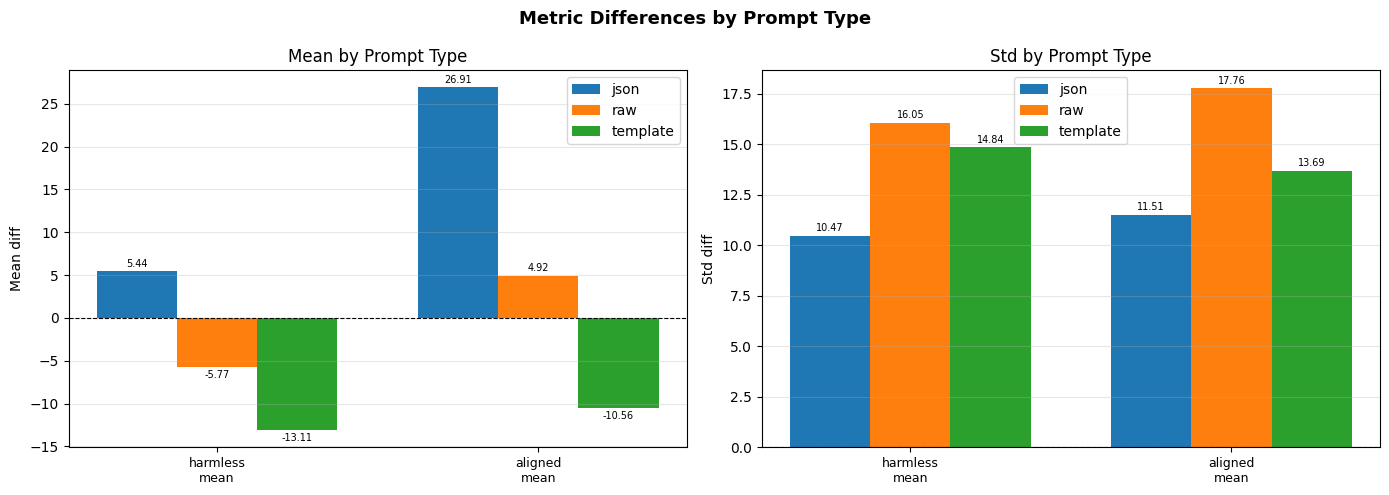

In [75]:
import matplotlib.pyplot as plt
import numpy as np

def plot_by_prompt_type(df, metrics, stats=['mean', 'std']):
    prompt_types = df['prompt_type'].unique()
    x = np.arange(len(metrics))
    width = 0.25
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
    
    for ax_idx, stat in enumerate(stats):
        ax = axes[ax_idx]
        for i, pt in enumerate(prompt_types):
            subset = df[df['prompt_type'] == pt]
            if stat == 'mean':
                vals = [subset[m].mean() for m in metrics]
            else:
                vals = [subset[m].std() for m in metrics]
            bars = ax.bar(x + i * width, vals, width, label=pt)
            ax.bar_label(bars, fmt='%.2f', fontsize=7, padding=2)
        
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_xticks(x + width)
        ax.set_xticklabels([m.replace('_diff', '').replace('_', '\n') for m in metrics], fontsize=9)
        ax.set_title(f'{stat.capitalize()} by Prompt Type')
        ax.set_ylabel(f'{stat.capitalize()} diff')
        ax.legend()
        ax.grid(axis='y', alpha=0.3)
    
    plt.suptitle('Metric Differences by Prompt Type', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('plot_by_prompt_type.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_by_prompt_type(
    df, 
    metrics = [
        'harmless_mean_diff', 
        'aligned_mean_diff', 
    ],
    stats = ["mean", "std"]
)

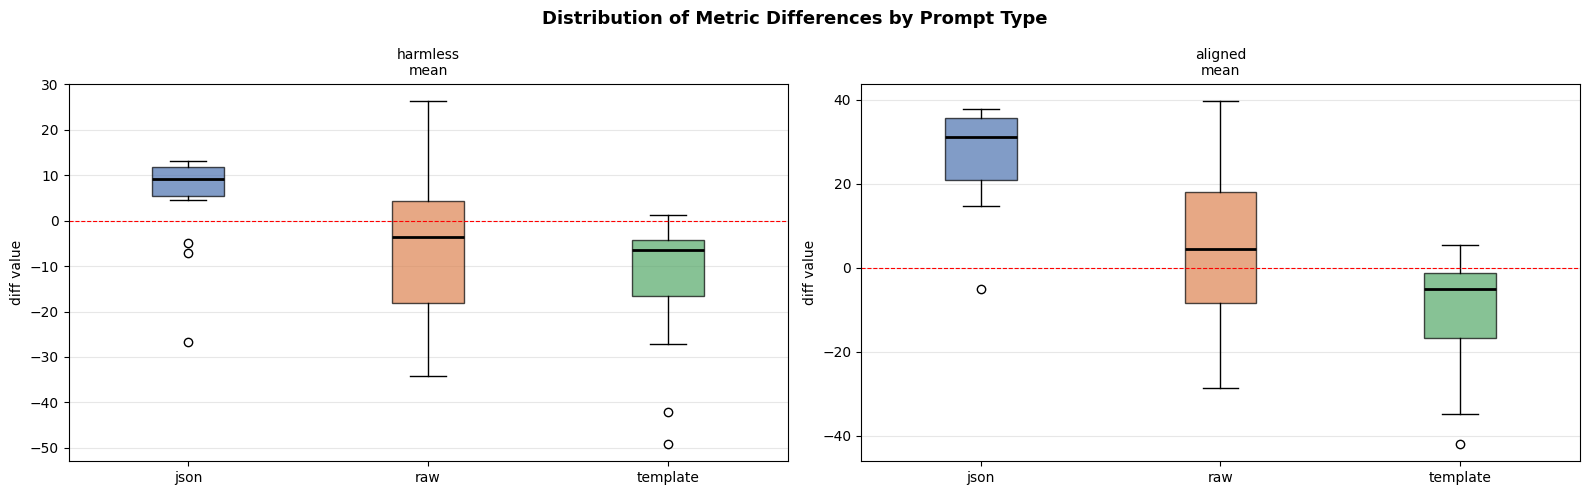

In [76]:
import matplotlib.pyplot as plt

def plot_boxplot_by_prompt_type(df, metrics):
    fig, axes = plt.subplots(1, len(metrics), figsize=(16, 5), sharey=False)
    
    for ax, metric in zip(axes, metrics):
        data_to_plot = [df[df['prompt_type'] == pt][metric].values 
                        for pt in df['prompt_type'].unique()]
        
        bp = ax.boxplot(data_to_plot, 
                        labels=df['prompt_type'].unique(),
                        patch_artist=True,
                        medianprops=dict(color='black', linewidth=2))
        
        # Color each box differently
        colors = ['#4C72B0', '#DD8452', '#55A868']
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.7)
        
        ax.axhline(0, color='red', linewidth=0.8, linestyle='--', label='baseline')
        ax.set_title(metric.replace('_diff', '').replace('_', '\n'), fontsize=10)
        ax.set_ylabel('diff value')
        ax.grid(axis='y', alpha=0.3)
    
    plt.suptitle('Distribution of Metric Differences by Prompt Type', 
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('boxplot_by_prompt_type.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_boxplot_by_prompt_type(df, metrics = [
        'harmless_mean_diff', 
        'aligned_mean_diff', 
    ],)

In [77]:
import json
import pandas as pd
import numpy as np

by_prompt_type = {x: v["agg_combined_prompt_type_compare"] for x, v in data.items()}
# --- Flatten into a DataFrame ---
rows = []
for filepath, entries in by_prompt_type.items():
    # Extract learning rate from filename
    # lr = filepath.split('_resp_')[1].replace('_fpq.csv', '')
    for entry in entries:
        rows.append(entry)

df = pd.DataFrame(rows)
metrics = ['harmless_mean', 'harmless_std', 'aligned_mean', 'aligned_std']

In [29]:
# raw['../generated_results_0312/eval_Qwen2.5-32B-Instruct_insecure_all_resp_1e-05_fpq.csv']

In [34]:
# data['../generated_results_general/eval_Qwen2.5-Coder-32B-Instruct_finance_all_resp_1e-05_general200nano.csv']

In [78]:
import json
import pandas as pd
import numpy as np

def add_sig_stars(df):
    df = df.copy()

    for col in df.columns:
        if isinstance(col, tuple):
            # MultiIndex case (e.g., agg)
            metric, stat = col
            if metric in ["ks_p", "w_p"]:
                df[col] = df[col].apply(
                    lambda x: f"{x:.4f}***" if x < 0.05 else f"{x:.4f}"
                )
            else:
                df[col] = df[col].apply(lambda x: f"{x:.4f}")
        else:
            # Single-level columns
            if col in ["ks_p", "w_p"]:
                df[col] = df[col].apply(
                    lambda x: f"{x:.4f}***" if x < 0.05 else f"{x:.4f}"
                )
            else:
                df[col] = df[col].apply(lambda x: f"{x:.4f}")

    return df
    
raw = {x: v["sc_results"] for x, v in data.items()}
raw_diff = {x: v["agg_combined_prompt_type"] for x, v in data.items()} 

rows = []
for path, metrics in raw.items():
    # parse filename parts
    name = path.split("/")[-1].replace(".csv", "")
    parts = name.split("_")
    # format: eval_{model}_{domain}_all_resp_{lr}_{suffix}
    model = "_".join(parts[1:-4])
    domain = parts[-4]
    lr = parts[-2]
    suffix = parts[-1]
    for metric_name, vals in metrics.items():
        rows.append({
            "model": model,
            "domain": domain,
            "lr": lr,
            "suffix": suffix,
            "metric": metric_name,
            "slope": vals["slope"],
            "r2": vals["r2"],
            "ks_stat": vals["ks_stat"],
            "ks_p": vals["ks_p"],
            "w_p": vals["w_p"],
            "pearson_stat": vals["pearson_stat"],
            "pearson_p": vals["pearson_p"],
        })

df = pd.DataFrame(rows)

relevant_columns = ["slope", "r2", "w_p", "pearson_stat", "pearson_p"]

# print("=" * 60)
# print("TOP-LEVEL AGGREGATE")
# print("=" * 60)
# agg = df.groupby("metric")[relevant_columns].agg(["mean", "median", "std"])
# print(agg.round(4).to_string())

print("\n" + "=" * 60)
print("BY DOMAIN FPQ - 1e-05")
print("=" * 60)
def get_domain(x):
    for d in ["finance", "medical", "insecure", "chem-bad-osf", "chem-high-osf"]:
        if d in x:
            return d
df["domain"] = df["model"].apply(get_domain)
subset = df[(df["suffix"]=="fpq")] # & (df["lr"]=="1e-05")
by_model = subset.groupby(["domain", "lr", "metric"])[relevant_columns].mean().round(4)
print(add_sig_stars(by_model).to_string())
print("\n" + "=" * 60)
print("BY LEARNING RATE")
print("=" * 60)
by_lr = df.groupby(["lr", "metric"])[relevant_columns].mean().round(4)
print(by_lr.to_string())

# print("\n" + "=" * 60)
# print("SIGNIFICANT RESULTS (ks_p < 0.05) COUNT BY METRIC")
# print("=" * 60)
# sig = df[df["ks_p"] < 0.05].groupby(["suffix", "metric"]).size().rename("sig_count")
# total = df.groupby(["suffix", "metric"]).size().rename("total")
# sig_rate = pd.concat([sig, total], axis=1).assign(rate=lambda x: (x.sig_count / x.total).round(3))
# print(sig_rate.to_string())
print("\n" + "=" * 60)
print("BY EVAL TASK")
print("=" * 60)
by_suffix = df.groupby(["suffix", "metric"])[relevant_columns].mean().round(4)
print(by_suffix.to_string())
print("\n" + "=" * 60)


BY DOMAIN FPQ - 1e-05
                                             slope      r2        w_p pearson_stat pearson_p
domain        lr    metric                                                                  
chem-bad-osf  1e-05 aligned_mean_compare   -0.0393  0.0026  0.0395***      -0.0512    0.8122
                    aligned_std_compare    -0.3362  0.0440  0.0006***      -0.2098    0.3250
                    harmless_mean_compare   0.2144  0.0829     0.3748       0.2879    0.1725
                    harmless_std_compare   -0.0100  0.0001     0.2292      -0.0093    0.9656
              3e-05 aligned_mean_compare    0.0467  0.0066     0.4559       0.0815    0.7048
                    aligned_std_compare     0.2090  0.0853     0.1208       0.2921    0.1660
                    harmless_mean_compare   0.4758  0.2088  0.0126***       0.4570    0.0248
                    harmless_std_compare    0.3309  0.1036  0.0138***       0.3218    0.1251
chem-high-osf 1e-05 aligned_mean_compare   -0.0

In [82]:
print("SIGNIFICANT RESULTS (w_p < 0.05) COUNT BY METRIC")
print("=" * 60)
groups = ["suffix", "metric"]
wilcoxon_sig5 = df[df["w_p"] < 0.05].groupby(groups).size().rename("wilcoxon_sig5")
pearson_sig5 = df[df["pearson_p"] < 0.05].groupby(groups).size().rename("pearson_sig5")
wilcoxon_sig1 = df[df["w_p"] < 0.01].groupby(groups).size().rename("wilcoxon_sig1")
pearson_sig1 = df[df["pearson_p"] < 0.01].groupby(groups).size().rename("pearson_sig1")
total = df.groupby(groups).size().rename("total")

# Combine everything
result = pd.concat([total, wilcoxon_sig5, pearson_sig5, wilcoxon_sig1, pearson_sig1], axis=1).fillna(0)

# Compute rates
result["wilcoxon_sig_rate_0.05"] = (result["wilcoxon_sig5"] / result["total"]).round(3)
result["pearson_sig_rate_0.05"] = (result["pearson_sig5"] / result["total"]).round(3)
result["wilcoxon_sig_rate_0.01"] = (result["wilcoxon_sig1"] / result["total"]).round(3)
result["pearson_sig_rate_0.01"] = (result["pearson_sig1"] / result["total"]).round(3)
result= result.drop(['wilcoxon_sig5', 'pearson_sig5', 'wilcoxon_sig1', 'pearson_sig1'], axis=1)

by_suffix = df.groupby(groups)[[
    "pearson_stat", 
    # "pearson_p", 
]].mean().round(4)
result = pd.concat([result, by_suffix], axis=1)
result.to_csv("comparison_rates.csv")
print(result.to_string())

SIGNIFICANT RESULTS (w_p < 0.05) COUNT BY METRIC
                                      total  wilcoxon_sig_rate_0.05  pearson_sig_rate_0.05  wilcoxon_sig_rate_0.01  pearson_sig_rate_0.01  pearson_stat
suffix         metric                                                                                                                                  
fpq            aligned_mean_compare      16                   0.625                  0.312                   0.375                  0.188        0.2299
               aligned_std_compare       16                   0.812                  0.062                   0.688                  0.000        0.0679
               harmless_mean_compare     16                   0.438                  0.375                   0.312                  0.000        0.2791
               harmless_std_compare      16                   0.438                  0.125                   0.250                  0.125        0.2222
general200nano aligned_mean_compare    

In [83]:
result

total  wilcoxon_sig_rate_0.05  \
suffix         metric                                                 
fpq            aligned_mean_compare      16                   0.625   
               aligned_std_compare       16                   0.812   
               harmless_mean_compare     16                   0.438   
               harmless_std_compare      16                   0.438   
general200nano aligned_mean_compare       5                   1.000   
               aligned_std_compare        5                   1.000   
               harmless_mean_compare      5                   0.600   
               harmless_std_compare       5                   0.800   
hbp            aligned_mean_compare       7                   1.000   
               aligned_std_compare        7                   0.857   
               harmless_mean_compare      7                   1.000   
               harmless_std_compare       7                   0.857   

                                      pearson_sig_rate_0.05  \
suffix         metric                                         
fpq            aligned_mean_compare                   0.312   
               aligned_std_compare                    0.062   
               harmless_mean_compare                  0.375   
               harmless_std_compare                   0.125   
general200nano aligned_mean_compare                   0.600   
               aligned_std_compare                    0.200   
               harmless_mean_compare                  1.000   
               harmless_std_compare                   0.800   
hbp            aligned_mean_compare                   0.857   
               aligned_std_compare                    0.571   
               harmless_mean_compare                  0.857   
               harmless_std_compare                   0.714   

                                      wilcoxon_sig_rate_0.01  \
suffix         metric                                          
fpq            aligned_mean_compare                    0.375   
               aligned_std_compare                     0.688   
               harmless_mean_compare                   0.312   
               harmless_std_compare                    0.250   
general200nano aligned_mean_compare                    1.000   
               aligned_std_compare                     0.800   
               harmless_mean_compare                   0.600   
               harmless_std_compare                    0.800   
hbp            aligned_mean_compare                    0.857   
               aligned_std_compare                     0.714   
               harmless_mean_compare                   1.000   
               harmless_std_compare                    0.714   

                                      pearson_sig_rate_0.01  pearson_stat  
suffix         metric                                                      
fpq            aligned_mean_compare                   0.188        0.2299  
               aligned_std_compare                    0.000        0.0679  
               harmless_mean_compare                  0.000        0.2791  
               harmless_std_compare                   0.125        0.2222  
general200nano aligned_mean_compare                   0.200        0.1670  
               aligned_std_compare                    0.000        0.0806  
               harmless_mean_compare                  0.600        0.3031  
               harmless_std_compare                   0.800        0.2118  
hbp            aligned_mean_compare                   0.857        0.3028  
               aligned_std_compare                    0.571        0.0735  
               harmless_mean_compare                  0.857        0.2980  
               harmless_std_compare                   0.714        0.1815

In [ ]:
"""
Reproduces the cross-validated R² plot from Table 4.

Data: Cross-validated R² with 95% CI, CV p-value, and permutation test
results. Y variable is "harmless" score; X variables are differences in
variance ratios on PCs 0-140.
"""

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ---------------------------------------------------------------------------
# Data from Table 4
# ---------------------------------------------------------------------------
groups = [
    "Qwen 32B\nFinance – General\n(n=1414)",
    "Qwen Coder-32B\nFinance – Harm.\n(n=320)",
    "Qwen Coder-32B\nInsecure Code\n(n=320)",
]

# Each entry: (cv_r2, ci_lo, ci_hi, perm_r2, null_ci_lo, null_ci_hi)
last_data = [
    (0.33, 0.32, 0.34,  0.32, -0.02, 0.00),
    (0.51, 0.49, 0.53,  0.50, -0.22, -0.02),
    (0.37, 0.35, 0.39,  0.39, -0.21, -0.03),
]

mean_data = [
    (0.48, 0.46, 0.49,  0.45, -0.02, 0.00),
    (0.52, 0.50, 0.54,  0.52, -0.23, -0.04),
    (0.21, 0.18, 0.23,  0.23, -0.19, -0.03),
]

# ---------------------------------------------------------------------------
# Plot styling (matches original)
# ---------------------------------------------------------------------------
BLUE_DARK  = "#2166ac"   # Last  – CV R²  (filled circle)
BLUE_LIGHT = "#74b9ff"   # Mean  – CV R²  (filled square)
GRAY_DARK  = "#555555"   # Last  – Perm R² (circle, dotted CI)
GRAY_LIGHT = "#aaaaaa"   # Mean  – Perm R² (square, dotted CI)

x = np.arange(len(groups))          # group positions
offset = 0.18                        # horizontal jitter between Last / Mean

fig, ax = plt.subplots(figsize=(8, 5.5))

for i, (last, mean) in enumerate(zip(last_data, mean_data)):
    xl = x[i] - offset   # x position for Last
    xm = x[i] + offset   # x position for Mean

    # --- CV R² markers with solid CIs ---
    # Last (dark blue circle)
    cv_lo = last[1]; cv_hi = last[2]; cv_r2 = last[0]
    ax.plot([xl, xl], [cv_lo, cv_hi], color=BLUE_DARK, lw=2.5, zorder=3)
    ax.plot(xl, cv_r2, 'o', color=BLUE_DARK, ms=9, zorder=4)

    # Mean (light blue square)
    cv_lo = mean[1]; cv_hi = mean[2]; cv_r2 = mean[0]
    ax.plot([xm, xm], [cv_lo, cv_hi], color=BLUE_LIGHT, lw=2.5, zorder=3)
    ax.plot(xm, cv_r2, 's', color=BLUE_LIGHT, ms=9, zorder=4)

    # --- Perm R² markers with dashed null CIs ---
    # Last (dark gray circle)
    perm_r2 = last[3]; null_lo = last[4]; null_hi = last[5]
    ax.plot([xl, xl], [null_lo, null_hi], color=GRAY_DARK,
            lw=1.8, linestyle='--', zorder=2)
    ax.plot(xl, perm_r2, 'o', color=GRAY_DARK, ms=8,
            markerfacecolor='white', markeredgewidth=1.8, zorder=3)

    # Mean (light gray square)
    perm_r2 = mean[3]; null_lo = mean[4]; null_hi = mean[5]
    ax.plot([xm, xm], [null_lo, null_hi], color=GRAY_LIGHT,
            lw=1.8, linestyle='--', zorder=2)
    ax.plot(xm, perm_r2, 's', color=GRAY_LIGHT, ms=8,
            markerfacecolor='white', markeredgewidth=1.8, zorder=3)

# ---------------------------------------------------------------------------
# Reference line at y = 0
# ---------------------------------------------------------------------------
ax.axhline(0, color='#999999', lw=0.8, linestyle='dotted', zorder=1)

# ---------------------------------------------------------------------------
# Axes formatting
# ---------------------------------------------------------------------------
ax.set_xticks(x)
ax.set_xticklabels(groups, fontsize=10)
ax.set_ylabel("R²", fontsize=12)
ax.set_ylim(-0.35, 0.72)
ax.set_xlim(-0.6, len(groups) - 0.4)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', color='#e0e0e0', lw=0.8, zorder=0)

# ---------------------------------------------------------------------------
# Legend
# ---------------------------------------------------------------------------
legend_elements = [
    mpatches.Patch(color='none'),   # spacer – filled below with Line2D proxies
]

from matplotlib.lines import Line2D

leg = [
    Line2D([0], [0], marker='o', color=BLUE_DARK,  lw=2,   ms=8,
           label='Last – CV R²'),
    Line2D([0], [0], marker='s', color=BLUE_LIGHT, lw=2,   ms=8,
           label='Mean – CV R²'),
    Line2D([0], [0], marker='o', color=GRAY_DARK,  lw=1.8, ms=8,
           linestyle='--', markerfacecolor='white', markeredgewidth=1.5,
           label='Last – Perm R²'),
    Line2D([0], [0], marker='s', color=GRAY_LIGHT, lw=1.8, ms=8,
           linestyle='--', markerfacecolor='white', markeredgewidth=1.5,
           label='Mean – Perm R²'),
]
ax.legend(handles=leg, ncol=2, fontsize=9,
          loc='upper center', bbox_to_anchor=(0.5, 1.13),
          frameon=False, columnspacing=1.5)

# ---------------------------------------------------------------------------
# Footer note
# ---------------------------------------------------------------------------
fig.text(
    0.05, 0.01,
    "All CV p-values ≈ 0.00 except Insecure Code – Mean (p = 0.0013).\n"
    "All permutation p-values = 0.002, the minimum achievable given 500 permutations.",
    fontsize=7.5, color='#555555', style='italic', va='bottom'
)

plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.savefig("r2_plot_reproduced.pdf", bbox_inches='tight')
print("Saved r2_plot_reproduced.pdf")
plt.show()